In [1]:
# Perform the necessary imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

iris_df = pd.read_csv("../Data/Iris.csv")
iris_df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
iris = load_iris()
print(iris.data[:5]) 

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


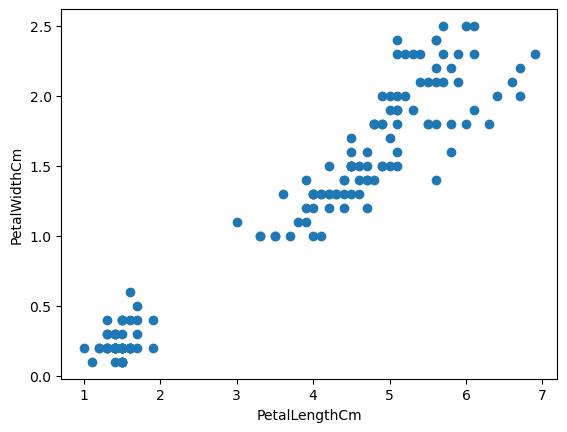

In [3]:
# positional indexing on a DataFrame
xs = iris_df.iloc[:, 3]
ys = iris_df.iloc[:, 4]

plt.scatter(xs, ys)
plt.xlabel('PetalLengthCm')
plt.ylabel('PetalWidthCm')
plt.show()

In [4]:
# Performing k-Means clustering and predicted the labels of new points
iris = load_iris()
points = iris.data 

In [5]:
# create a KMeans instance with 3 clusters (Iris has 3 species)
model = KMeans(n_clusters=3, n_init=10)

# fit and predict on the same data — no separate new_points needed
labels = model.fit_predict(points)

# print cluster labels
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


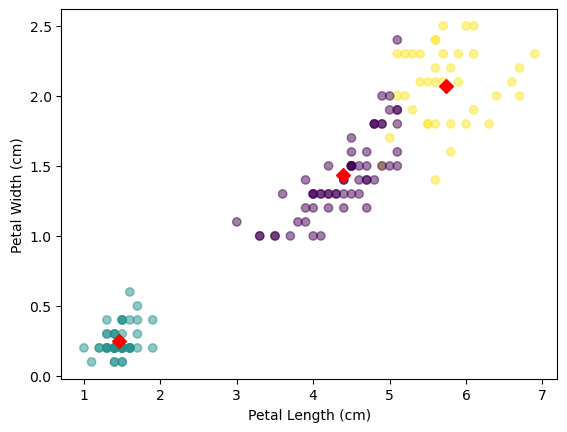

In [6]:

# Assign the columns of points: xs and ys (using petal length/width, indices 2 and 3)
xs = points[:, 2]
ys = points[:, 3]

# Make a scatter plot of xs and ys, using labels to define the colors
plt.scatter(xs, ys, c=labels, alpha=0.5)

# Assign the cluster centers: centroids
centroids = model.cluster_centers_

# Assign the columns of centroids: centroids_x, centroids_y (same feature columns as xs/ys)
centroids_x = centroids[:, 2]
centroids_y = centroids[:, 3]

# Make a scatter plot of centroids_x and centroids_y
plt.scatter(centroids_x, centroids_y, marker='D', s=50, c='red')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()

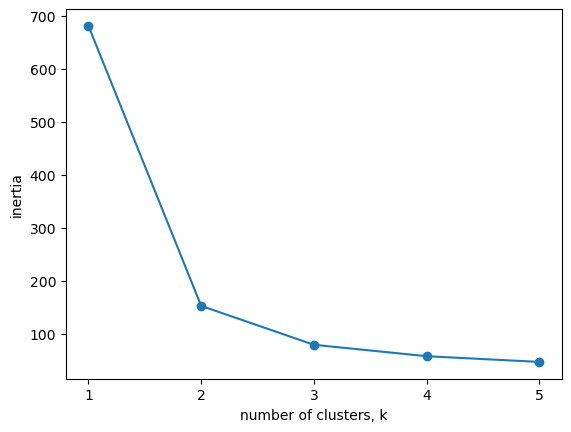

In [7]:
# Range of k values to try (elbow method for choosing optimal clusters)
samples = points
ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters
    model = KMeans(n_clusters=k, n_init=10)  
    # Fit model to samples
    model.fit(samples)
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot ks vs inertias (outside the loop — runs once after all k values tested)
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

The code runs KMeans clustering with k values from 1 to 5, recording each model's inertia (a measure of cluster tightness), then plots k against inertia to visually identify the "elbow" — the point where increasing k stops meaningfully reducing inertia — giving us a data-driven estimate for the optimal number of clusters rather than guessing arbitrarily. It looks like 3 clusters are the appropriate number of clusters for this dataset. 

In [8]:
# map numeric target labels (0,1,2) to their actual species names

# Create a KMeans model with 3 clusters
varieties = pd.Categorical.from_codes(iris.target, iris.target_names)
model = KMeans(n_clusters=3, n_init=10)  

# Fit model and obtain cluster labels in one step
labels = model.fit_predict(samples)

# Create a DataFrame with labels and varieties as columns
df = pd.DataFrame({'labels': labels, 'varieties': varieties})

# Create crosstab: cross-tabulate cluster labels against real variety names
ct = pd.crosstab(df['labels'], df['varieties'])

# Display ct
print(ct)

varieties  setosa  versicolor  virginica
labels                                  
0              50           0          0
1               0          48         14
2               0           2         36


The crosstab shows that KMeans did a strong job rediscovering the true species groupings without ever seeing the labels: cluster 1 is a near-perfect match for setosa (all 50 samples), cluster 2 captures most of versicolor (48 of 50) with a few virginica mixed in, and cluster 0 is dominated by virginica (36 of 50) but picks up some versicolor overlap too — so the model cleanly separates setosa from the other two species, while versicolor and virginica, which are known to overlap more in feature space, get slightly blended between clusters 0 and 2.

In [9]:
# Load Palmer Penguins dataset
url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(url)

print(penguins.head())
# Drop rows with missing values
penguins = penguins.dropna()

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  


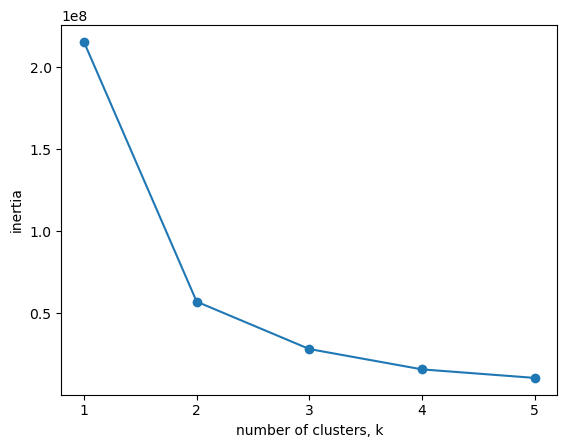

In [10]:
# Range of k values to try (elbow method for choosing optimal clusters)
samples = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].values  # penguins features

ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters
    model = KMeans(n_clusters=k, n_init=10)
    # Fit model to samples
    model.fit(samples)
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot ks vs inertias (outside the loop — runs once after all k values tested)
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [11]:
# Select numeric features for clustering
samples_penguin = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].values

print(samples[:5])

# Ground-truth species labels for later comparison
species = penguins['species'].values

[[  39.1   18.7  181.  3750. ]
 [  39.5   17.4  186.  3800. ]
 [  40.3   18.   195.  3250. ]
 [  36.7   19.3  193.  3450. ]
 [  39.3   20.6  190.  3650. ]]


In [12]:
# Create scaler: scaler
scaler = StandardScaler()  # transforming features to have mean 0 and std of 1 so all features have equal weight
# standardizes features by removing the mean and scaling to unit variance

# Create KMeans instance: kmeans
kmeans = KMeans(n_clusters=3, n_init=10)  # 3 clusters to match the 3 known penguin species

# Create pipeline: pipeline
pipeline = make_pipeline(scaler, kmeans)

In [13]:
# Fit the pipeline to samples
pipeline.fit(samples_penguin)

# Calculate the cluster labels: labels
labels = pipeline.predict(samples_penguin)

# Create a DataFrame with labels and species as columns: df
df = pd.DataFrame({'labels': labels, 'species': species})

# Create crosstab: ct
ct = pd.crosstab(df['labels'], df['species'])

# Display ct
print(ct)

species  Adelie  Chinstrap  Gentoo
labels                            
0           124          5       0
1             0          0     119
2            22         63       0


KMeans successfully rediscovered the real penguin species almost entirely from just physical measurements, with no access to the species labels themselves: Gentoo forms a perfectly isolated cluster (cluster 1, 119 pure Gentoo), Adelie is nearly as clean (cluster 0, 124 of 146 Adelie with only minor Chinstrap bleed-through), while the only real confusion is between Adelie and Chinstrap in cluster 2 — a known overlap in bill and body measurements between these two species, reflecting genuine biological similarity rather than a clustering failure.

In [14]:
# raw price data: rows = companies, columns = dates, values = daily closing price
url = 'https://raw.githubusercontent.com/mesfind/datasets/master/company-stock-movements-2010-2015-incl.csv'
stocks_df = pd.read_csv(url, index_col=0)

print(stocks_df.head())

                  2010-01-04  2010-01-05  2010-01-06  2010-01-07  2010-01-08  \
Apple               0.580000   -0.220005   -3.409998   -1.170000    1.680011   
AIG                -0.640002   -0.650000   -0.210001   -0.420000    0.710001   
Amazon             -2.350006    1.260009   -2.350006   -2.009995    2.960006   
American express    0.109997    0.000000    0.260002    0.720002    0.190003   
Boeing              0.459999    1.770000    1.549999    2.690003    0.059997   

                  2010-01-11  2010-01-12  2010-01-13  2010-01-14  2010-01-15  \
Apple              -2.689994   -1.469994    2.779997   -0.680003   -4.999995   
AIG                -0.200001   -1.130001    0.069999   -0.119999   -0.500000   
Amazon             -2.309997   -1.640007    1.209999   -1.790001   -2.039994   
American express   -0.270001    0.750000    0.300004    0.639999   -0.130001   
Boeing             -1.080002    0.360000    0.549999    0.530002   -0.709999   

                  ...  2013-10-16  201

In [15]:
movements = stocks_df.values

In [16]:
# Create a normalizer: normalizer which rescales each sample
normalizer = Normalizer()

# Create a KMeans model with 10 clusters: kmeans
kmeans = KMeans(n_clusters = 10, n_init = 10)

# Make a pipeline chaining normalizer and kmeans: pipeline
pipeline = make_pipeline(normalizer, kmeans)

# Fit pipeline to the daily price movements
pipeline.fit(movements)

Pipeline(steps=[('normalizer', Normalizer()),
                ('kmeans', KMeans(n_clusters=10, n_init=10))])

In [17]:
# Extract company names from the DataFrame's index (row labels) as a plain array
companies = stocks_df.index.values

# Predict the cluster labels: labels
labels = pipeline.predict(movements)

# Create a DataFrame aligning labels and companies: df
df = pd.DataFrame({'labels': labels, 'companies': companies})

# Display df sorted by cluster label
print(df.sort_values('labels'))

    labels                           companies
12       0                             Chevron
23       0                                 IBM
42       0                   Royal Dutch Shell
20       0                          Home Depot
43       0                                 SAP
44       0                        Schlumberger
16       0                   General Electrics
39       0                              Pfizer
58       0                               Xerox
13       0                   DuPont de Nemours
41       0                       Philip Morris
25       0                   Johnson & Johnson
10       0                      ConocoPhillips
8        0                         Caterpillar
30       0                          MasterCard
53       0                       Valero Energy
31       0                           McDonalds
32       0                                  3M
3        0                    American express
57       0                               Exxon
49       0   

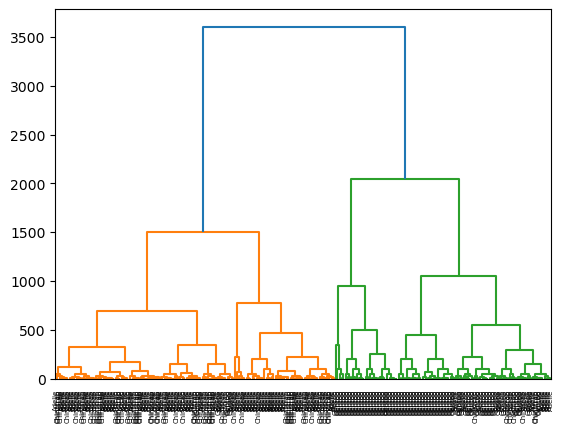

In [20]:
# Extract ground-truth species labels for dendrogram x-axis labeling (not used in clustering itself)
varieties = penguins['species'].tolist()

# Calculate the linkage: mergings (hierarchical clustering using complete linkage method)
mergings = linkage(samples_penguin, method='complete')

# Plot the dendrogram, using species varieties as leaf labels
dendrogram(mergings,
           labels=varieties,
           leaf_rotation=90,   # rotate labels 90 degrees so they don't overlap
           leaf_font_size=5)   # small font size to fit all labels given the sample size
plt.show()